<a href="https://colab.research.google.com/github/gisele-mgs/especializacacin/blob/main/visaocomp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto - Visao Computacional com Deep Learning

O objetivo deste projeto é desenvolver um modelo de deep learning capaz de classificar automaticamente o uso e cobertura do solo em imagens RGB do conjunto EuroSAT. Essas imagens, capturadas pelo satélite Sentinel-2 e organizadas em tiles de 64×64 pixels, representam dez categorias distintas de paisagem — de cultivos e vegetação a áreas urbanas, corpos d’água e infraestrutura.

A tarefa envolve construir um pipeline supervisionado completo — desde o carregamento e pré-processamento das imagens até o treinamento de uma CNN própria e de um modelo com Transfer Learning — garantindo documentação clara e justificativa técnica para cada escolha.

Por se tratar de imagens relativamente pequenas, com resolução espacial limitada e variações reais de qualidade, o problema exige que o modelo consiga extrair padrões espaciais e texturais robustos a partir de um canal espectral restrito (RGB). O desafio, portanto, é construir uma solução consistente, reprodutível e bem fundamentada, aplicada a um cenário real de classificação de cenas de sensoriamento remoto.

In [ ]:
import torch
torch.cuda.is_available()


False

In [ ]:
import kagglehub # importação do kaggle para carregar dados

# Download da última versão
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

# caminho do arquivo
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Path to dataset files: /kaggle/input/eurosat-dataset


In [ ]:
!pip install rastreio

##Setup

In [ ]:
import pandas as pd

In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True # ativa opção para permitir carregar imagens corrompidas/truncadas


In [ ]:
!pip install jpeg4py


  Preparing metadata (setup.py) ... done
  Created wheel for jpeg4py: filename=jpeg4py-0.1.4-py3-none-any.whl size=8426 sha256=4658d811ebd0360cc97a0843a5e603adb3b7c26b6cae53044a9521d88dbb003e
  Stored in directory: /root/.cache/pip/wheels/ab/a3/c5/3fce1e4f84180fa8362da30c3db4c719be956d49a0da49bd47
Successfully built jpeg4py


In [ ]:
#!pip install torchsummary
import torch
from PIL import Image
import rastreio
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from torch import nn, optim, functional
from torch.utils import data

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from torchsummary import summary
import os

In [ ]:
import numpy as np
import random

In [ ]:
def set_seed(seed):
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Leave as True to ensure determinism. Some operations may crash
    torch.use_deterministic_algorithms(False)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

## Dataset e Dataloaders

  Dataset para carregar imagens EuroSAT RGB (10 classes). csv_path (str): caminho do CSV (train.csv, validation.csv, test.csv) root (str): pasta raiz contendo as pastas das classes transform: transforms.Compose(...) com resize, tensor e normalização

Transformação do EUROSAT para um dataset pytorch

In [ ]:
class EuroSATRGB(Dataset):
    def __init__(self, csv_path, root, transform=None, label=None):


        # lê o CSV — ele deve conter:
        # 'filename' -> caminho relativo da imagem
        # 'label'    -> rótulo numérico
        self.df = pd.read_csv(csv_path)

        # pasta raiz onde ficam as pastas do dataset (Ex.: AnnualCrop/, Forest/, etc.)
        self.root = root

        # transformações de pré-processamento
        self.transform = transform

        # targets e caminhos
        self.targets = self.df["Label"].astype(int).to_numpy()
        self.filenames = self.df["Filename"].to_numpy()

    def __len__(self):
        """Retorna o número total de amostras no dataset."""
        return len(self.df)

    def __getitem__(self, idx):
        """
        Recupera uma imagem e o seu rótulo associado.
        """

        # path relativo vindo do CSV
        filename = self.df.iloc[idx]['Filename']

        # path absoluto completo
        img_path = os.path.join(self.root, filename)

        # lÊ a imagem e converte para RGB (garante 3 canais)
        img = Image.open(img_path).convert("RGB")
        # rotulo numérico
        label = int(self.df.iloc[idx]['Label'])



        # Aplica transformações (Tensor + Normalize)
        if self.transform:
            img = self.transform(img)

        return img, label


In [ ]:
!cp -r /kaggle/input/eurosat-dataset/EuroSAT


cp: missing destination file operand after '/kaggle/input/eurosat-dataset/EuroSAT'
Try 'cp --help' for more information.


In [ ]:

root = "/kaggle/input/eurosat-dataset/EuroSAT"

# Caminho dos CSVs de treino, validação e teste
train_csv = os.path.join(root, "train.csv")
val_csv   = os.path.join(root, "validation.csv")
test_csv  = os.path.join(root, "test.csv")

print(train_csv)
print(val_csv)
print(test_csv)


/kaggle/input/eurosat-dataset/EuroSAT/train.csv
/kaggle/input/eurosat-dataset/EuroSAT/validation.csv
/kaggle/input/eurosat-dataset/EuroSAT/test.csv


Utiliando um conjunto de transform para:
1. Redimensionar a imagem para o tamanho 224x224
2.  transforma a imagem UInt8 para float
3. normaliza normalização por canal (R, G, B)

    Estes valores de média e desvio padrão foram calculados previamente usando o EuroSAT RGB
    

In [ ]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    # para:
    #   tensor PyTorch (C×H×W) em 0–1.
    transforms.ToTensor(),



    transforms.Normalize(
        mean=[0.3443, 0.3802, 0.4086],  # médias reais calculadas no dataset
        std=[0.2037, 0.1362, 0.1315]    # desvios padrões reais
    )
])


In [ ]:


train_dataset = EuroSATRGB(train_csv, root, transform)
val_dataset   = EuroSATRGB(val_csv, root, transform)
test_dataset  = EuroSATRGB(test_csv, root, transform)



para cnn própria:



As imagens foram redimensionadas para 64×64 para compatibilidade com a CNN, enquanto a ResNet50 exige entrada de 224x224.

Estou testando o data agumentation
o original era:


transform = transforms.Compose([

transforms.Resize((64, 64)),
    
 # para:
#   tensor PyTorch (C×H×W) em 0–1.
transforms.ToTensor(),

    
    
transforms.Normalize(
mean=[0.3443, 0.3802, 0.4086],  # médias reais calculadas no dataset
std=[0.2037, 0.1362, 0.1315]    # desvios padrões reais
    ) ])


In [ ]:
tfcnn = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),#
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.3443, 0.3802, 0.4086],
        std=[0.2037, 0.1362, 0.1315]
    )
])


In [ ]:


cnntrain = EuroSATRGB(train_csv, root, tfcnn)
cnnval   = EuroSATRGB(val_csv, root, tfcnn)
cnntest  = EuroSATRGB(test_csv, root, tfcnn)




In [ ]:
BATCH_SIZE_TR = 256 # treino - batch size
BATCH_SIZE_TS = 512 # test - batch size


In [ ]:
LR = 1e-4 # learning rate


In [ ]:
train_loader = data.DataLoader(
    train_dataset, num_workers=2, pin_memory=True,
    batch_size=BATCH_SIZE_TR, shuffle=True
)

val_loader = data.DataLoader(
    val_dataset, num_workers=2, pin_memory=True,
    batch_size=BATCH_SIZE_TS, shuffle=True
)

test_loader = data.DataLoader(
    test_dataset, num_workers=2, pin_memory=True,
    batch_size=BATCH_SIZE_TS, shuffle=True
)

In [ ]:
train_loader_cnn = data.DataLoader(
    cnntrain, num_workers=2, pin_memory=True,
    batch_size=32, shuffle=True
)

val_loader_cnn = data.DataLoader(
    cnnval, num_workers=2, pin_memory=True,
    batch_size=32, shuffle=True
)

test_loader_cnn = data.DataLoader(
    cnntest, num_workers=2, pin_memory=True,
    batch_size=32, shuffle=True
)

In [ ]:
print("treino:", len(train_dataset))
print("validação:", len(val_dataset))
print("teste:", len(test_dataset))


treino: 18900
validação: 5400
teste: 2700


In [ ]:
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dbbf1f01da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dbbf1f01da0>
Traceback (most recent call last)

torch.Size([256, 3, 224, 224]) torch.Size([256])


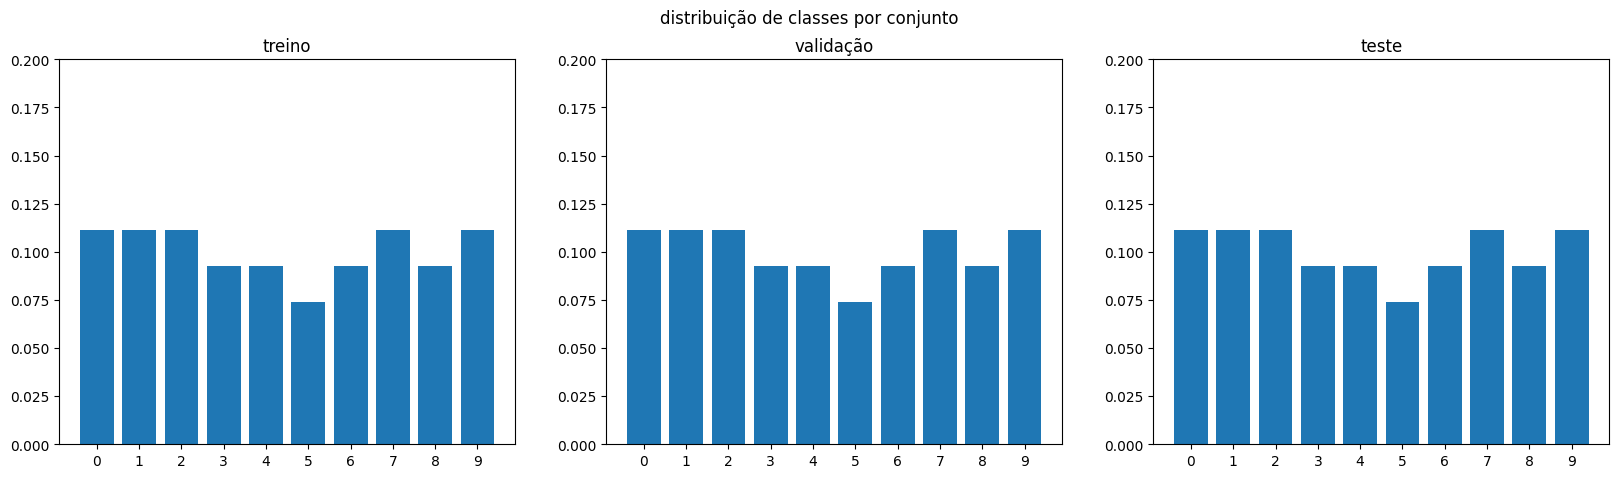

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
plt.suptitle("distribuição de classes por conjunto")

datasets = [train_dataset, val_dataset, test_dataset]
names = ["treino", "validação", "teste"]

for i, ds in enumerate(datasets):
    labels = ds.targets
    counts = {k: 0 for k in range(10)}

    for t in labels:
        counts[int(t)] += 1 / len(labels)

    ax[i].bar(counts.keys(), counts.values())
    ax[i].set_xticks(range(10))
    ax[i].set_ylim([0, 0.2])
    ax[i].set_title(names[i])

plt.show()


In [ ]:
# Carrega o CSV de treino
df = pd.read_csv(train_csv)

# Número de classes
num_classes = df['Label'].nunique()
print("Número de classes:", num_classes)

# Mapeamento Label → ClassName
class_map = dict(sorted(df[['Label', 'ClassName']].drop_duplicates().values.tolist()))
print(class_map)



Número de classes: 10
{0: 'AnnualCrop', 1: 'Forest', 2: 'HerbaceousVegetation', 3: 'Highway', 4: 'Industrial', 5: 'Pasture', 6: 'PermanentCrop', 7: 'Residential', 8: 'River', 9: 'SeaLake'}


In [ ]:
print(train_dataset.df.head())
print(train_dataset.df.dtypes)


   Unnamed: 0                                           Filename  Label  \
0       16257                      AnnualCrop/AnnualCrop_142.jpg      0   
1        3297  HerbaceousVegetation/HerbaceousVegetation_2835...      2   
2       17881               PermanentCrop/PermanentCrop_1073.jpg      6   
3        2223                      Industrial/Industrial_453.jpg      4   
4        4887  HerbaceousVegetation/HerbaceousVegetation_1810...      2   

              ClassName  
0            AnnualCrop  
1  HerbaceousVegetation  
2         PermanentCrop  
3            Industrial  
4  HerbaceousVegetation  
Unnamed: 0     int64
Filename      object
Label          int64
ClassName     object
dtype: object


## Transfer learning

In [ ]:
from torch.nn import functional as F
from tqdm import tqdm

Executa uma época completa de treinamento do modelo.Calcula perda média e acurácia média, mostrando progresso com tqdm.

  Parâmetros: dataloader: batches de dados de treinamentomodel: rede neural loss_fn: função de perda (CrossEntropyLoss) optimizer: Adam, SGD etc. device: cpu ou cuda

Retorna:
        avg_loss: perda média da época
        avg_acc: acurácia média da época


In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer, device):

    # Ativa modo treino:
    # - Dropout ON
    # - BatchNorm usa estatísticas do batch
    model.train()

    # Acumuladores manuais de estatísticas
    total_loss = 0.0          # soma das perdas ponderada pelo batch
    total_correct = 0         # total de acertos
    total_samples = 0         # total de amostras processadas

    # tqdm para barra de progresso
    pbar = tqdm(dataloader, desc="Treinando", unit="batch")

    # Loop pelos batches
    for batch, (X, y) in enumerate(pbar):

        # Envia dados para GPU/CPU onde o modelo está
        X, y = X.to(device), y.to(device)

        # Forward pass — modelo gera previsões
        pred = model(X)

        # Calcula perda entre previsão e rótulos verdadeiros
        loss = loss_fn(pred, y)

        # backpropagation

        optimizer.zero_grad()     # zera gradientes
        loss.backward()           # retropropaga erro
        optimizer.step()          # atualiza pesos do modelo

        # estatísticas

        batch_size = X.size(0)

        # soma da perda total do batch (loss * número de amostras)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        # cálculo de acertos no batch
        preds = pred.argmax(dim=1)    # classe prevista
        total_correct += (preds == y).sum().item()

        # atualiza barra de progresso
        current_loss = total_loss / total_samples
        current_acc = total_correct / total_samples
        pbar.set_postfix(loss=current_loss, acc=current_acc)

    # ----- estatísticas finais da época -----

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    print(f"treino loss: {avg_loss:.6f} | treino acc: {avg_acc:.6f}")

    return avg_loss, avg_acc


Essa função avalia o desempenho do modelo em um conjunto de dados sem atualizar gradientes.Usado para validação (durante o treino) ou teste (avaliação final).


In [ ]:


def evaluation_loop(dataloader, model, loss_fn, device, label="Validation"):


    # Modo de avaliação:
    # - desativa dropout
    # - batchnorm usa running mean/variance
    model.eval()

    # Variáveis para acumular resultados
    total_loss = 0.0         # soma ponderada da loss
    total_correct = 0        # soma de acertos
    total_samples = 0        # número total de amostras processadas

    # Desativa o cálculo de gradientes:
    # -> reduz uso de memória
    # -> aumenta velocidade
    with torch.no_grad():

        # tqdm
        pbar = tqdm(dataloader, desc=label, unit="batch")

        for X, y in pbar:
            # Envia inputs e labels para a GPU/CPU correta
            X, y = X.to(device), y.to(device)

            # Forward-pass: apenas inferência (sem backward)
            pred = model(X)

            # calcula a perda do batch
            loss = loss_fn(pred, y)

            # obtém o tamanho do batch atual
            batch_size = X.size(0)

            # acumula perda ponderada:
            # soma(loss * tamanho_do_batch)
            # Isso gera média correta, mesmo se últimos batches forem menores
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            # calcula acurácia do batch:
            # argmax → classe com maior logit
            preds = pred.argmax(dim=1)

            # conta número de previsões corretas
            total_correct += (preds == y).sum().item()

            # calcula métricas parciais para exibir no tqdm
            current_loss = total_loss / total_samples
            current_acc = total_correct / total_samples

            # atualiza descrição da barra de progresso
            pbar.set_postfix(loss=current_loss, acc=current_acc)

    # cálculo final das métricas da época inteira
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    # Impressão final após encerrar o tqdm
    print(f"{label} loss: {avg_loss:.6f} | {label} acc: {avg_acc:.6f}\n")

    # Retorna métricas para registro/plotagem
    return avg_loss, avg_acc


## função para treino e validação do modelo por várias épocas.
  
    Usa as funções:
        - train_loop
        - evaluation_loop

    Retorna:
        history: dicionário contendo listas com:
            - perda e acurácia de treino
            - perda e acurácia de validação


In [ ]:
def train_model(
    model,
    num_epochs,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    device
):


    # Dicionário para guardar histórico
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }


    for epoch in range(num_epochs):
        print(f"\n epoca {epoch+1}/{num_epochs}")

        # treinamento
        train_loss, train_acc = train_loop(
            train_loader, model, loss_fn, optimizer, device
        )

        # validação
        val_loss, val_acc = evaluation_loop(
            val_loader, model, loss_fn, device, label="val"
        )

        #  armazena no histórico
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)


    return  history


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # tentativa de otimizar tempo de execução
device

device(type='cpu')

In [ ]:
from torchvision import models

# ResNet50

 Iremos carregar a  ResNet50 pré-treinada nos pesos do ImageNet.
 pesos pré-treinados trazem representações gerais (bordas, texturas, formas) que aceleram a convergência e melhoram desempenho em datasets pequenos/medios.

In [ ]:
def build_resnet50(num_classes=10, freeze=True):


    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    if freeze:
          for param in model.parameters():
              param.requires_grad = False



    # substitui a fully-connected final (fc) por uma nova camada adequada ao número de classes.

    #  original foi treinada para as 1000 classes do ImageNet;
    #  precisamos de uma camada final  com saída igual ao num_classes.


    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)


    return model




In [ ]:
model = build_resnet50(num_classes=10, freeze=True).to(device)

# otimização com channels_last
model = model.to(memory_format=torch.channels_last)

# garante que apenas a camada final
# (e outras eventualmente descongeladas) sejam de fato atualizadas.
# optimizador apenas para parâmetros treináveis
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3   # Learning Rate:controla o tamanho dos passos de atualização
)
 # Função de perda usada para classificação multiclasse.
loss_fn = nn.CrossEntropyLoss()

num_epochs = 6


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 118MB/s]


In [ ]:
train_loss = []
val_loss = []
train_losses = []
val_losses = []

In [ ]:
history = train_model(
    model=model,
    num_epochs=6,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device
)



 epoca 1/6


Treinando:   0%|          | 0/591 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Treinando:   3%|▎         | 17/591 [00:10<05:52,  1.63batch/s, acc=0.366, loss=1.94]


KeyboardInterrupt: 

In [ ]:
#visualização das curvas de treino e validação
fig = plt.figure()
plt.plot(history["train_loss"], label='train', color='green') # curva de perda no treinamento
plt.plot(history["val_loss"], label='valid', color='red')    # curva de perda na validação
plt.legend()
plt.show()

In [ ]:
all_preds = [] # armazenar valores previstos
all_targets = [] # armazenar valores reais

total_corrects = 0
total_n = 0



In [ ]:
for instances, targets in test_loader:
    instances, targets = instances.to(device), targets.to(device)
    with torch.no_grad():
        preds = model(instances)
    preds = nn.functional.softmax(preds, dim=1)
    preds = torch.argmax(preds, 1)

    total_corrects += (preds == targets).sum().item()
    total_n += len(instances)

    all_preds.append(preds.unsqueeze(-1))
    all_targets.append(targets.unsqueeze(-1))

In [ ]:
imgs.shape, labels.shape

In [ ]:
acc = total_corrects / total_n
print(f"Test Accuracy: {100 * acc:.2f}%")

Acuracia de 94% é um ótimo indicio que o modelo conseguiu generalizar para os dados de teste;

In [ ]:
# concatenação de predições e targets em tensores únicos

preds = torch.cat(all_preds).squeeze(-1).cpu()
targets = torch.cat(all_targets).squeeze(-1).cpu()
# verificação dos formatos de tensores
preds.shape, targets.shape

In [ ]:
# --- Matriz de confusão ---

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.grid(False)

labels = list(class_map.values())

cm = confusion_matrix(targets, preds)
cm_display = ConfusionMatrixDisplay(cm, display_labels=labels)
cm_display.plot(ax=ax, xticks_rotation=35.0)

In [ ]:
print(classification_report(targets, preds, target_names=labels, zero_division=0))

ResNet resultou um acuracia satisfátoria em todas as classes.
Em uma analise de melhoria foco deve ser nas classes de menor Recall e Precision que foram River e Highway para entender a natureza das suas confusões e aplicar técnicas como Fine-Tuning ou Data Augmentation mais agressivo nessas amostras específicas.

# CNN própria


1. **Input** →
2. **Conv+ReLU** (extrai padrões locais) →
3. **MaxPool** (reduz dimensão, foca no essencial) →
    
    (2–3 repetem algumas vezes) →
    
4. **Flatten + FC** (combina tudo e decide a classe) →
5. **Softmax/Output** →
6. **Loss** (compara com **Label**) →
7. **Backprop** (gradientes por toda a rede) →
8. **Update** (ajusta **kernels** e **weights** com o otimizador).

CNN  para classificar imagens da base EuroSAT.
        
        O modelo recebe imagens RGB de 64×64 pixels e atribui as 10 categorias distintas de cobertura/uso do solo. A arquitetura segue um padrão
        de extração de características através de blocos convolucionais seguidos
        por um classificador  conectado.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:


# definição do bloco convolucional reutilizável
def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
    """
    Bloco Conv2D + BatchNorm + ReLU + MaxPool
    """
    return nn.Sequential(
        nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                  kernel_size=kernel_size, stride=stride, padding=padding),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        # nn.MaxPool2d(kernel_size=2, stride=2)   # stride=2 reduz pela metade a HxW
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU()
    )

# classe CNN usando os conv_blocks
class euroCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        # Blocos convolucionais
        self.features = nn.Sequential(
            conv_block(3, 64),     # Input: 3x64x64 -> Output: 64x32x32
            conv_block(64, 128),   # 128x16x16
            conv_block(128, 256),  # 256x8x8
            conv_block(256, 512),  # 512x4x4
            nn.AdaptiveAvgPool2d((1,1))  # força saída 512x1x1
        )

        # Classificador
        self.classifier = nn.Sequential(
            nn.Flatten(),       # 512x1x1 -> 512
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x




In [ ]:
 # inicializacao modelo, loss e optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelCNN = euroCNN(n_classes=10).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelCNN.parameters(), lr=1e-3)


        1. A imagem passa pelos blocos convolucionais (extração de características).
        2. O mapa resultante é achatado.
        3. O MLP produz as logits para classificação.


In [ ]:
BATCH_SIZE_TR = 32


In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()


In [ ]:

summary(modelCNN, input_size=(3, 64, 64), device=device.type)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           1,792
       BatchNorm2d-2           [-1, 64, 64, 64]             128
              ReLU-3           [-1, 64, 64, 64]               0
         MaxPool2d-4           [-1, 64, 32, 32]               0
            Conv2d-5          [-1, 128, 32, 32]          73,856
       BatchNorm2d-6          [-1, 128, 32, 32]             256
              ReLU-7          [-1, 128, 32, 32]               0
         MaxPool2d-8          [-1, 128, 16, 16]               0
            Conv2d-9          [-1, 256, 16, 16]         295,168
      BatchNorm2d-10          [-1, 256, 16, 16]             512
             ReLU-11          [-1, 256, 16, 16]               0
        MaxPool2d-12            [-1, 256, 8, 8]               0
           Conv2d-13            [-1, 512, 8, 8]       1,180,160
      BatchNorm2d-14            [-1, 51

In [ ]:
#del model
#torch.cuda.empty_cache()


In [ ]:
historycnn = train_model(
    model=modelCNN,
    num_epochs=10,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device
)



 epoca 1/10


Treinando: 100%|██████████| 591/591 [09:40<00:00,  1.02batch/s, acc=0.591, loss=1.15]


treino loss: 1.154661 | treino acc: 0.590952


val: 100%|██████████| 169/169 [01:00<00:00,  2.77batch/s, acc=0.75, loss=0.69]


val loss: 0.689512 | val acc: 0.750370


 epoca 2/10


...

Treinando: 100%|██████████| 591/591 [08:19<00:00,  1.18batch/s, acc=0.824, loss=0.543]


treino loss: 0.542699 | treino acc: 0.824021


val: 100%|██████████| 169/169 [00:53<00:00,  3.16batch/s, acc=0.864, loss=0.418]


val loss: 0.417588 | val acc: 0.864074


 epoca 7/10


Treinando:  33%|███▎      | 195/591 [02:45<05:24,  1.22batch/s, acc=0.838, loss=0.512]

In [ ]:
#visualização das curvas de treino e validação
fig = plt.figure()
plt.plot(historycnn["train_loss"], label='train', color='green') # curva de perda no treinamento
plt.plot(historycnn["val_loss"], label='valid', color='red')    # curva de perda na validação
plt.legend()
plt.show()

In [ ]:
all_preds = [] # armazenar valores previstos
all_targets = [] # armazenar valores reais

total_corrects = 0
total_n = 0

# loop de teste — SEM gradiente
for imgs, labels in test_loader_cnn:
    imgs, labels = imgs.to(device), labels.to(device)
    with torch.no_grad(): # evita cálculo de gradientes
        preds = modelCNN(imgs)
     # converte logits em probabilidades
    preds = nn.functional.softmax(preds, dim=1)
    # classe com maior probabilidade (predição final)
    preds = torch.argmax(preds, 1)

    total_corrects += (preds == labels).sum().item()
    total_n += len(imgs)
  # armazena para análise posterior
    all_preds.append(preds.unsqueeze(-1)) # dimensão organizada

In [ ]:
acc_cnn = total_corrects / total_n
print(f"Test Accuracy: {100 * acc_cnn:.2f}%")

In [ ]:
x = torch.randn(1,3,64,64).to(device)
print(modelCNN.features(x).shape)


Foi utilizado como material de apoio para o desenvolvimento desse pipeline:

1. https://github.com/Rumeysakeskin/EuroSat-Satellite-CNN-and-ResNet/blob/main/train_cnn.ipynb
2. https://github.com/MuhammedM294/EuroSat (usei como base para CNN)
3. https://www.kaggle.com/code/mohamedelnahry/land-type-classification-eurosat
4. https://medium.com/@robin.hamers/cnn-recognizer-scaling-up-from-terrestrial-objects-to-satellite-views-c8128906c1f5
5. https://www.kaggle.com/code/whinerfox/simple-baseline


Foi utilizado também, referente a monitoria:


1. monitoria_classificacao_de_imagens.ipynb

2. [v2] Monitoria - VGG e Transfer Learning.ipynb


MIT License

Copyright (c) 2025 José Gabriel Pereira Tavares

Permission is hereby granted, free of charge, to any person obtaining a
copy of this software and associated documentation files (the "Software"),
to deal in the Software without restriction, including without limitation
the rights to use, copy, modify, merge, publish, distribute, sublicense,
and/or sell copies of the Software, and to permit persons to whom the
Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
DEALINGS IN THE SOFTWARE.



